# odor_space_sampling — Example Usage

This notebook walks through the full functionality of the package, organized into four sections:

1. **Loading data** — getting your CSV into the right format
2. **Exploring the odor space** — visualizing properties of the full dataset before sampling
3. **Sampling** — running the sampling methods and tuning GMM parameters
4. **Evaluating samples** — comparing how well each method covers the space

---
## 1. Loading data

`load_and_prepare` is the main entry point. It takes a CSV with a `smiles` column, computes RDKit descriptors, removes missing or zero variance features, z-scores, and reduces with PCA to 99% explained variance. It returns an `OdorData` object that bundles the original dataframe (`data.df`) and the processed matrix (`data.x`) together.

In [4]:
from odor_space_sampling import load_and_prepare

data = load_and_prepare("../data/gslf_and_human_data.csv")

print(f"{len(data.df)} odors loaded")
print(data.df.head())

generating descriptors: 100%|██████████| 5841/5841 [00:18<00:00, 308.18it/s]

initial data shape: (5841, 217)
dimension after removing constant features: (5841, 193)
dimensionality of 99% explained variance: 107
reduced space shape (5841, 107)
5841 odors loaded
                smiles     label    cid                    IUPAC
0      Cc1ccnc2ccccc12  ['gslf']  10285        4-methylquinoline
1  CC(C)c1ccnc2ccccc12  ['gslf']  74004     4-isopropylquinoline
2      Cc1cnc2ccccc2n1  ['gslf']  23686      2-methylquinoxaline
3     Cc1nc2ccccc2nc1C  ['gslf']  16925  2,3-dimethylquinoxaline
4      Cc1cccc2nccnc12  ['gslf']  61670      5-methylquinoxaline


### Adding CID and IUPAC names

If your CSV only has SMILES (no PubChem CIDs or IUPAC names), `add_cid_to_data` queries PubChem and adds them. It takes a file path and returns an enriched dataframe. Pass `save=True` to overwrite the original CSV. This example takes the csv "no_cid_test.csv" which has no CIDs or IUPAC names and addes them.

> **Note:** This hits the PubChem API once per molecule — keep the dataset small or be patient.

In [5]:
from odor_space_sampling import add_cid_to_data

# create a small example CSV with no CID/IUPAC columns
data.df[["smiles", "label"]].head(5).to_csv("../data/example/no_cid_test.csv", index=False)

enriched = add_cid_to_data("../data/example/no_cid_test.csv", save=False)
print(enriched)

generating CIDs: 5it [00:02,  2.36it/s]

                smiles     label    cid                    IUPAC
0      Cc1ccnc2ccccc12  ['gslf']  10285        4-methylquinoline
1  CC(C)c1ccnc2ccccc12  ['gslf']  74004     4-isopropylquinoline
2      Cc1cnc2ccccc2n1  ['gslf']  23686      2-methylquinoxaline
3     Cc1nc2ccccc2nc1C  ['gslf']  16925  2,3-dimethylquinoxaline
4      Cc1cccc2nccnc12  ['gslf']  61670      5-methylquinoxaline


---
## 2. Exploring the odor space

The following functions help with examining the data before sampling. You can look at the dimensionality, feature correlation, and functional group composition.

### Scree plot

Shows cumulative variance explained as PCA components are added. Useful for deciding how many dimensions to keep. NOTE: This has to regenerate rdkit descriptors because you wouldn't plot a scree plot of already dimensionality reduced data.

generating descriptors: 100%|██████████| 5841/5841 [00:19<00:00, 306.78it/s]


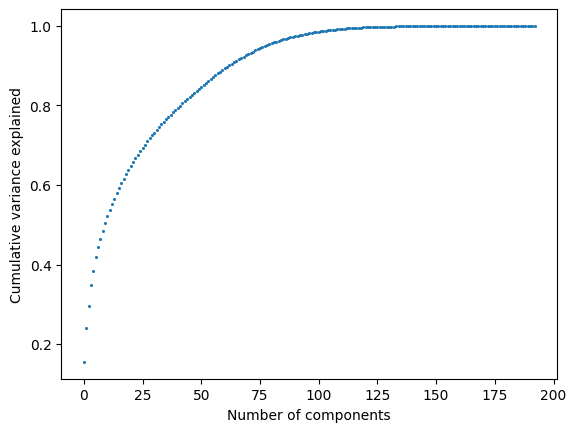

In [6]:
from odor_space_sampling import plot_scree_plot

plot_scree_plot(data)

### Feature covariance

Histogram of pairwise correlations between all features. A tight distribution around 0 means features are relatively independent. NOTE: This also has to regenerate rdkit descriptors because you wouldn't plot a scree plot of already dimensionality reduced data.

generating descriptors: 100%|██████████| 5841/5841 [00:19<00:00, 301.86it/s]


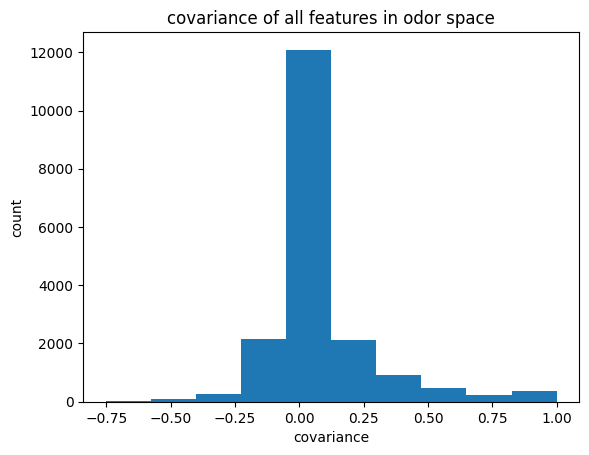

In [7]:
from odor_space_sampling import plot_feature_covariance

plot_feature_covariance(data)

### Functional group distribution

`plot_fun_group_dist` shows the normalized frequency of each RDKit functional group across the dataset. Pass a list of `(OdorData, label)` pairs to compare multiple datasets side-by-side. Use `density=False` to show raw counts instead.

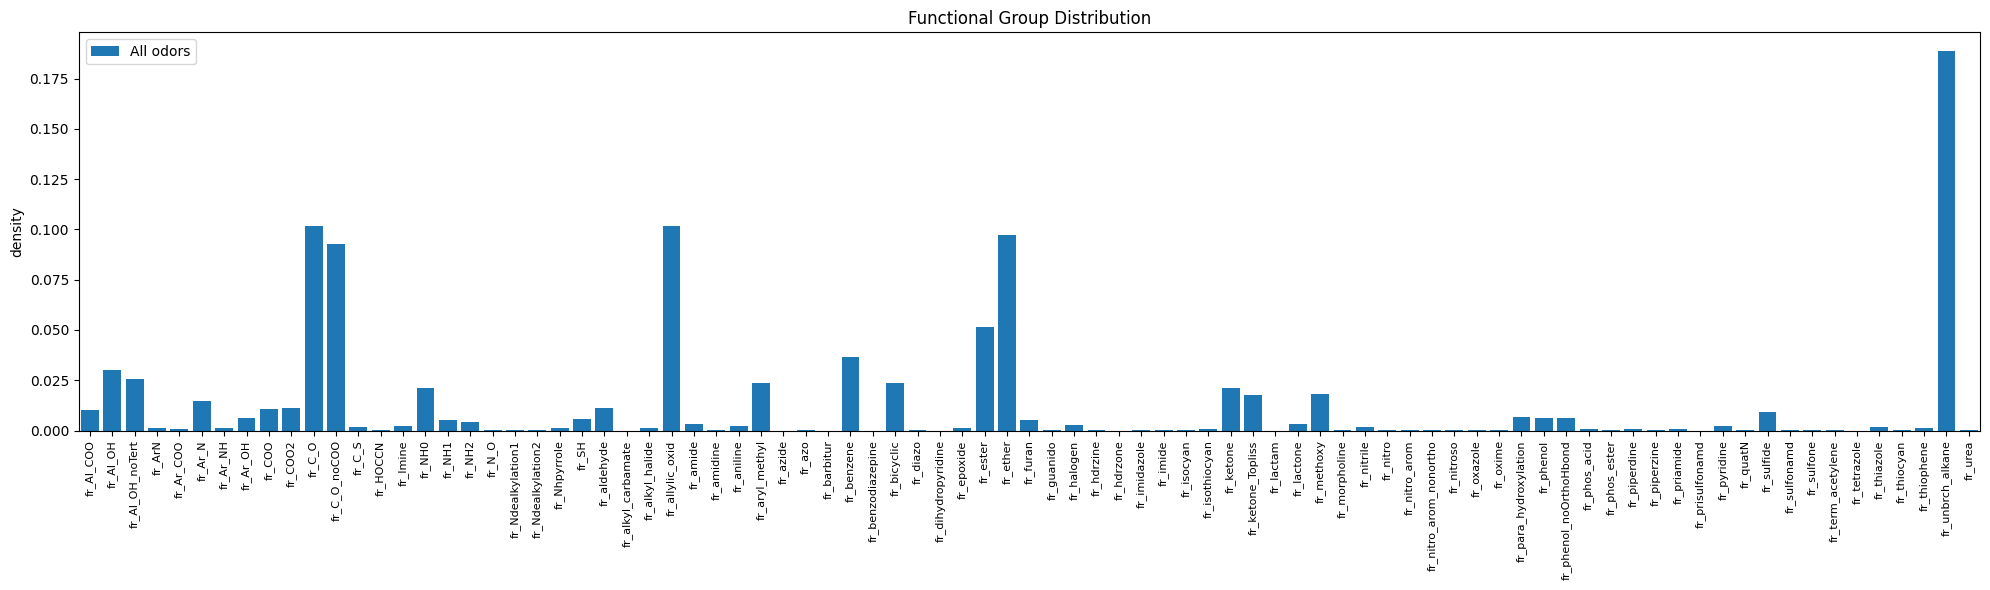

In [8]:
from odor_space_sampling import plot_fun_group_dist

# single dataset
plot_fun_group_dist(data, label="All odors")

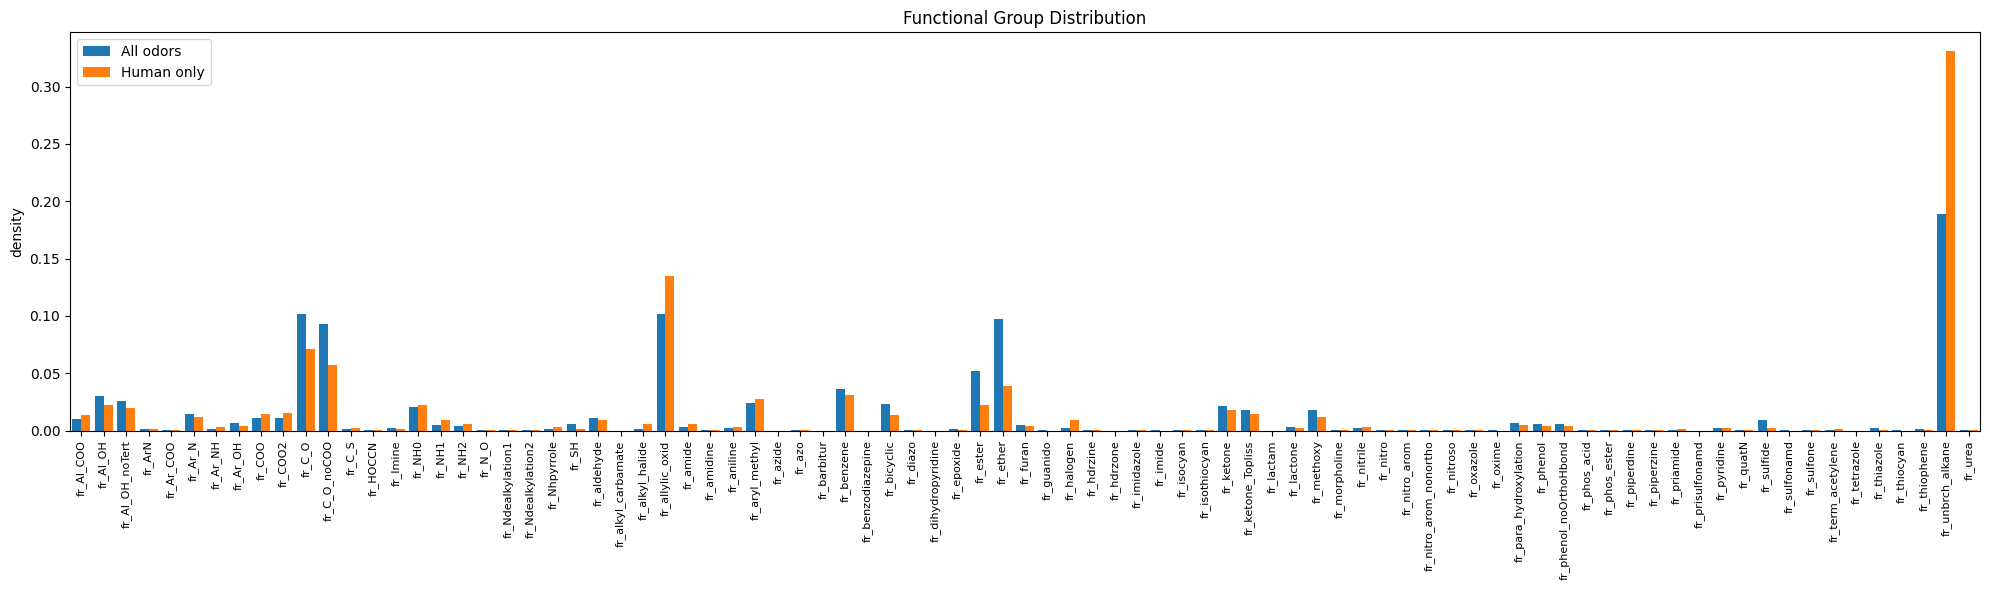

In [9]:
import pandas as pd
from odor_space_sampling import OdorData, load_and_prepare

# compare the full dataset against just the human-labelled subset
human_df = data.df[data.df['label'].str.contains('human')].reset_index(drop=True)
human_indices = data.df.index[data.df['label'].str.contains('human')].tolist()
data_human = OdorData(df=human_df, x=data.x[human_indices])

plot_fun_group_dist([
    (data,       "All odors"),
    (data_human, "Human only"),
])

---
## 3. Sampling

### Run all sampling methods at once

`sample_with_all_methods` runs all six strategies (uniform, LHS, Gaussian, min-max, KMeans, GMM) and returns a dict. Each value contains `samples`, `indices` (into `data.df`), and `distances`.

In [10]:
from odor_space_sampling import sample_with_all_methods

results = sample_with_all_methods(data, n_samples=100, seed=12345)

print("Methods:", list(results.keys()))

Methods: ['uniform', 'LHS', 'gaussian', 'min_max', 'kmeans', 'gmm']


### Getting the selected molecules

Use `indices` to look up the sampled molecules in `data.df`.

In [11]:
gmm_indices = results["gmm"]["indices"]
selected = data.df.iloc[gmm_indices]
print(selected.head())

# save to CSV
selected.to_csv("../data/example/gmm_sampled_molecules.csv", index=False)

                    smiles              label       cid  \
2454       CCCCCCCCCC=CC=O           ['gslf']     20967   
5148   CCCCCCCCC=CCCCCCCCC          ['human']    521661   
4055  O=C1CCC=CCCCCCCCCCC1           ['gslf']     84545   
3120   CCCCCCCCCCCCC(C)C=O           ['gslf']  11790917   
1250            CCCc1ccco1  ['human', 'gslf']     77907   

                         IUPAC  
2454              dodec-2-enal  
5148             octadec-9-ene  
4055  cyclopentadec-4-en-1-one  
3120      2-methyltetradecanal  
1250             2-propylfuran  


### Running a single sampling method

Each individual method is available directly. They all return `(samples, indices, distances)` and can be passed straight to `plot_sampling_projections`.

In [13]:
from odor_space_sampling.sampling import (
    uniform_sample, LHS_sampling, gaussian_sample,
    min_max_sample, kmeans_sample, gmm_sample
)

result = gmm_sample(data.x, n_gaussians=120, n_samples=100, seed=12345)
samples, indices, distances = result
print(f"Sampled {len(indices)} odors")
data.df.iloc[gmm_indices].to_csv("../data/example/gmm_sample_120_clusters.csv")  # can save if needed

Sampled 100 odors


### Choosing the number of GMM components

`aic_and_bic_gmm` sweeps over cluster counts and plots AIC, BIC, and KS statistics. Use the minimum to choose `n_clusters` for `get_n_closest_points_gmm` and `gmm_resample_varying_seeds`.

> **Note:** Slow — one GMM fit per cluster count. Keep `max_n_clusters` small while exploring.

fitting gmms: 100%|██████████| 20/20 [00:26<00:00,  1.33s/it]

Best AIC:       20 clusters
Best BIC:       14 clusters
Best KS median: 16 clusters


<Figure size 640x480 with 0 Axes>

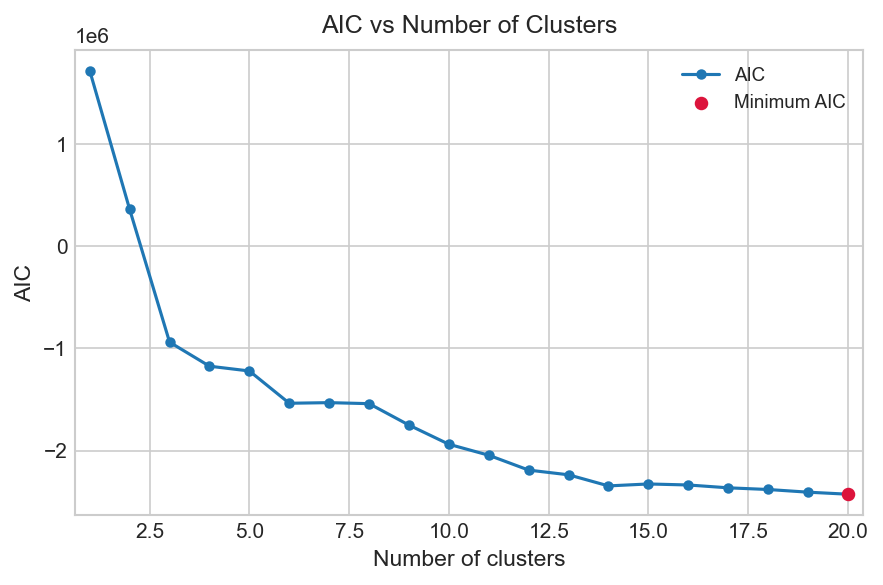

<Figure size 640x480 with 0 Axes>

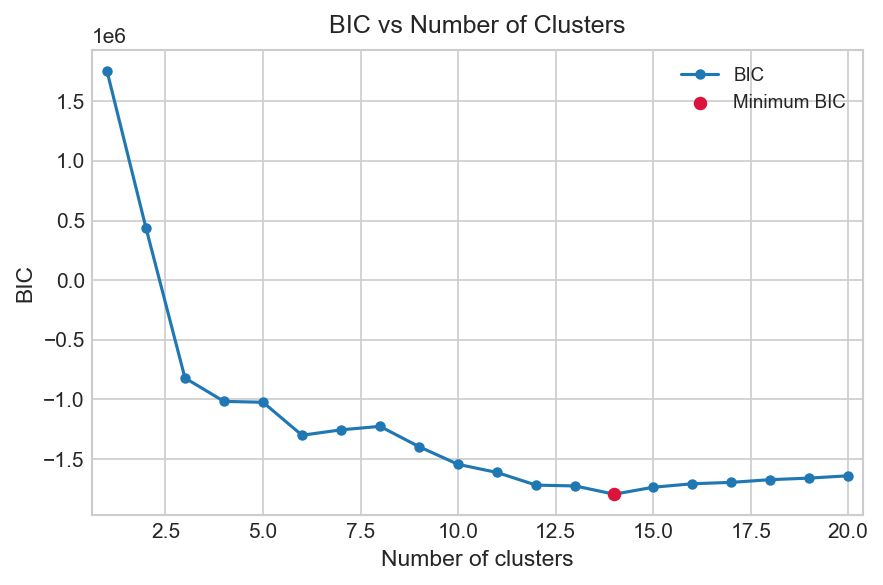

<Figure size 640x480 with 0 Axes>

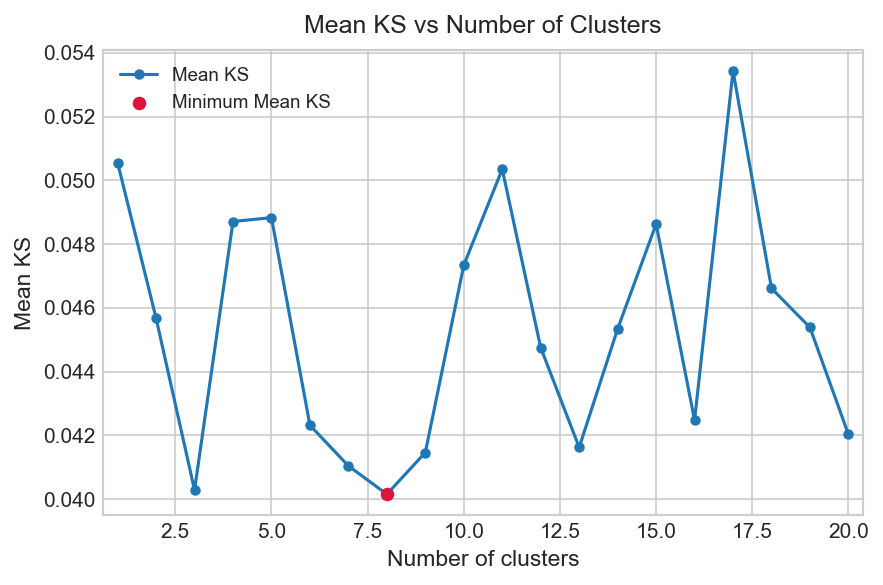

<Figure size 640x480 with 0 Axes>

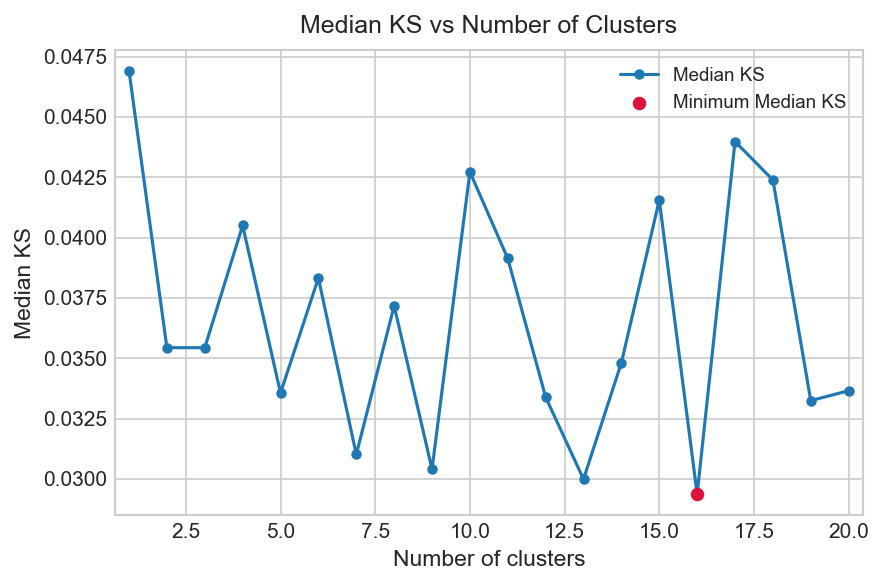

In [14]:
import numpy as np
from odor_space_sampling import aic_and_bic_gmm, plot_gmm_sweep

aics, bics, ks_means, ks_meds = aic_and_bic_gmm(data, max_n_clusters=20)

print(f"Best AIC:       {np.argmin(aics) + 1} clusters")
print(f"Best BIC:       {np.argmin(bics) + 1} clusters")
print(f"Best KS median: {np.argmin(ks_meds) + 1} clusters")

plot_gmm_sweep(aics, bics, ks_means, ks_meds)

### GMM — n closest real odors per sample

`get_n_closest_points_gmm` fits a GMM, samples from it, and returns the `n_closest_points` nearest real molecules to each sample. Useful when you want a ranked shortlist around each sampled point.

In [15]:
from odor_space_sampling import get_n_closest_points_gmm

closest = get_n_closest_points_gmm(
    data,
    n_closest_points=20,
    n_samples=100,
    n_clusters=120,
    seed=12345,
    save_path="../data/example/gmm_closest.csv"  # uncomment to save
)
print(closest)

      sample                   smiles              label      cid  \
0          0    CCCCCCCCCCCCCCCC(C)=O           ['gslf']    18027   
1          0    CCCCC=CCCCCCCCCCCCC=O           ['gslf']    94120   
2          0    CCCCCCCCC=CCCCCCCCC=O           ['gslf']    17029   
3          0     CCCCCCCCCCCCCCC(C)=O  ['human', 'gslf']    29251   
4          0    CCCCCCCCCCCCCCCC=CC=O           ['gslf']    41923   
...      ...                      ...                ...      ...   
1995      99          CCCCCCC1CCOC1=O           ['gslf']    86736   
1996      99  CC(C)=CCCC1(C)CCC(=O)O1           ['gslf']  9942315   
1997      99     CCCCCC=CCC1CCC(=O)O1           ['gslf']    62727   
1998      99       CCCCCCCC1CCC(=O)O1  ['human', 'gslf']     7714   
1999      99         CCCCC1OC(=O)CC1C           ['gslf']    62900   

                                                  IUPAC  
0                                      heptadecan-2-one  
1                                       octadec-13-enal

### GMM — resample with multiple seeds

`gmm_resample_varying_seeds` fits a fresh GMM for each seed and saves a separate CSV per seed. Useful for generating diverse sets of candidates from different GMM fits.

In [16]:
from odor_space_sampling import gmm_resample_varying_seeds

dfs = gmm_resample_varying_seeds(
    data=data,
    seeds=np.arange(5),
    n_clusters=120,
    n_samples=100,
    save_path="../data/example/multiseed/gmm_multiseed"  # uncomment to save
)
print(f"{len(dfs)} dataframes returned, one per seed")

iterating through seeds: 100%|██████████| 5/5 [00:39<00:00,  7.97s/it]

5 dataframes returned, one per seed


---
## 4. Evaluating and comparing samples

Once you have samples, these functions help you understand how well each method covers the space and what kinds of molecules were selected.

### Visualize sample placement in PCA and UMAP space

`plot_all_sampling_method_points` shows where each method placed its samples in a 2D projection. Grey = all odors, red = selected samples.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


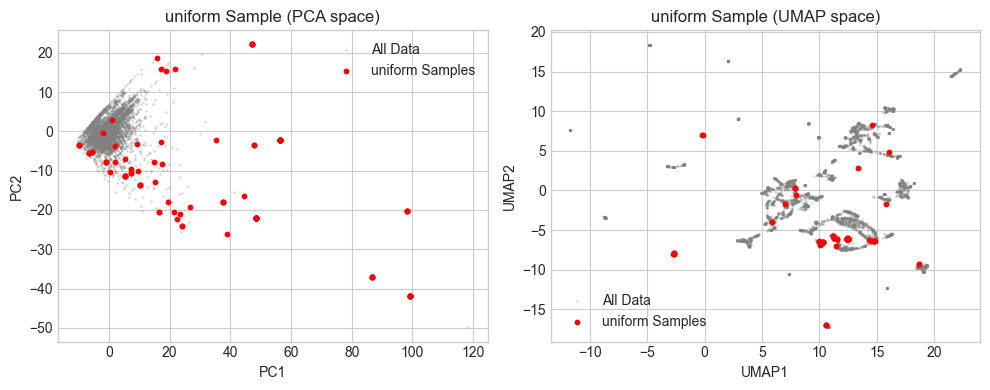

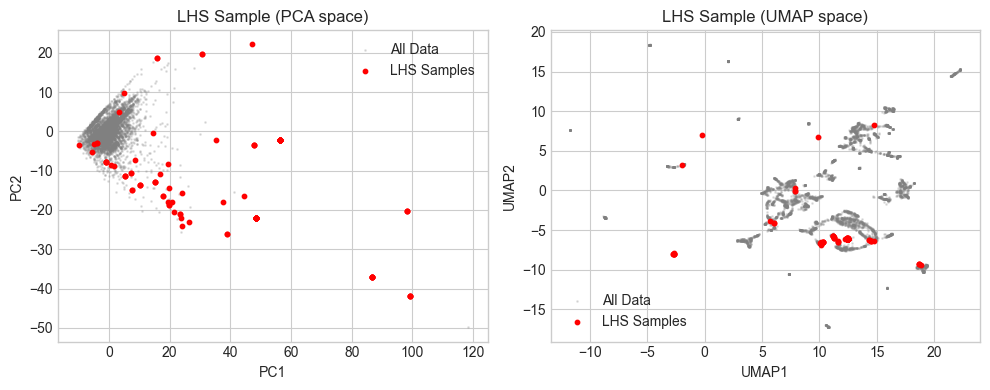

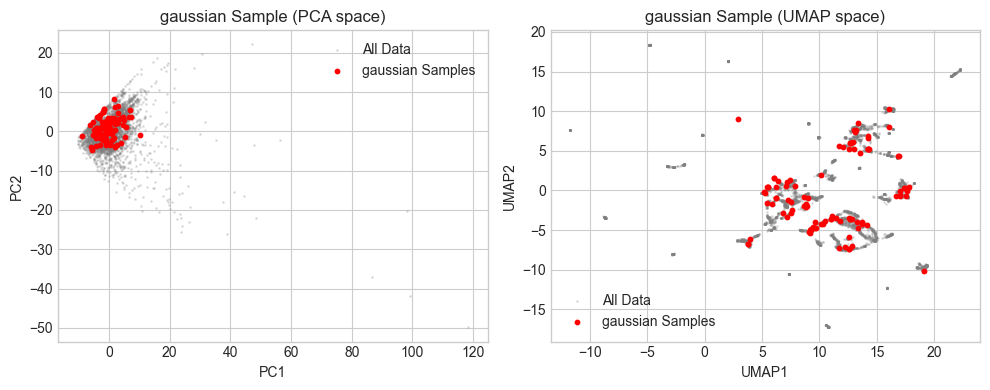

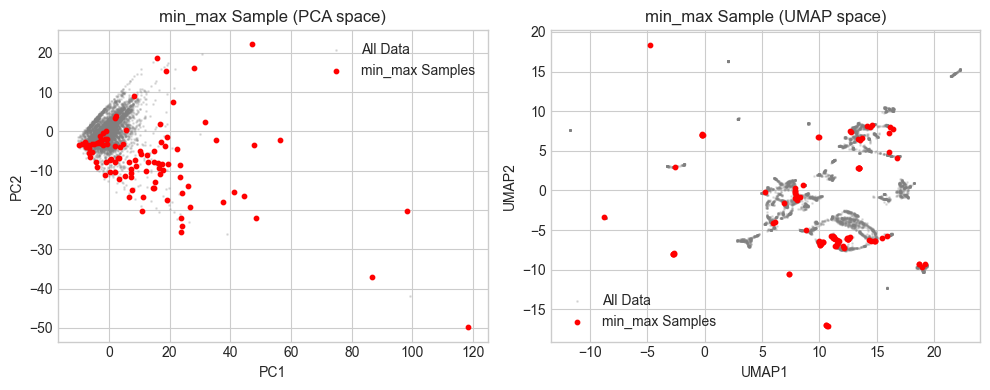

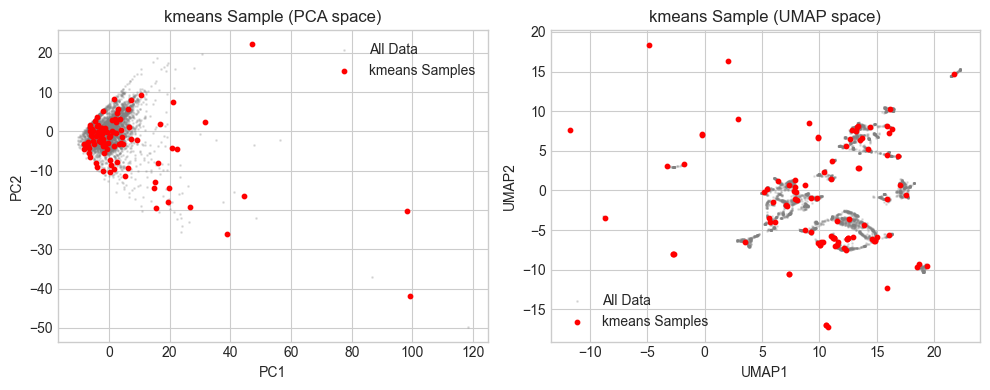

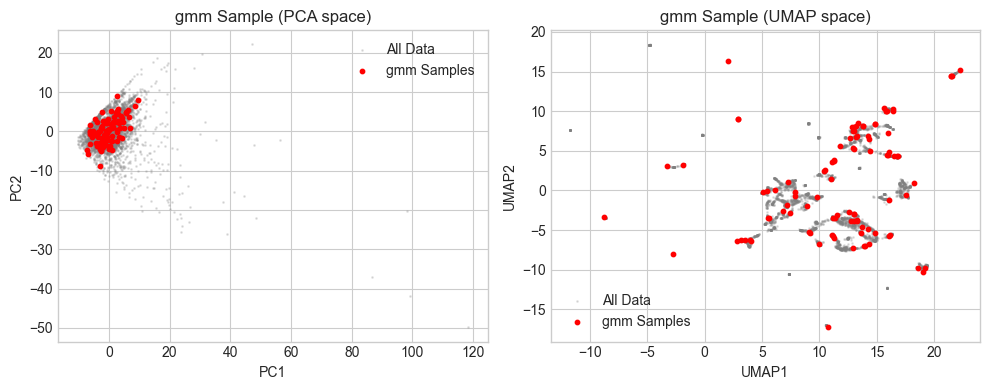

In [14]:
from odor_space_sampling import plot_all_sampling_method_points

plot_all_sampling_method_points(data, results)

You can also compare any mix of sampling results and external index sets using `plot_sampling_projections` directly.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


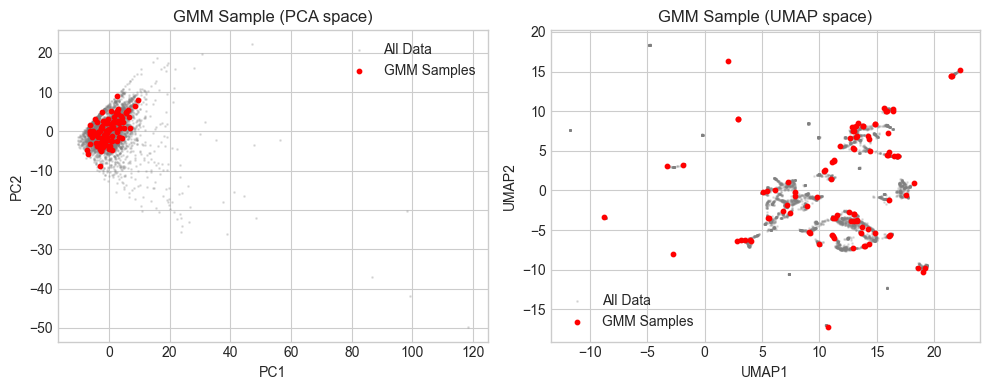

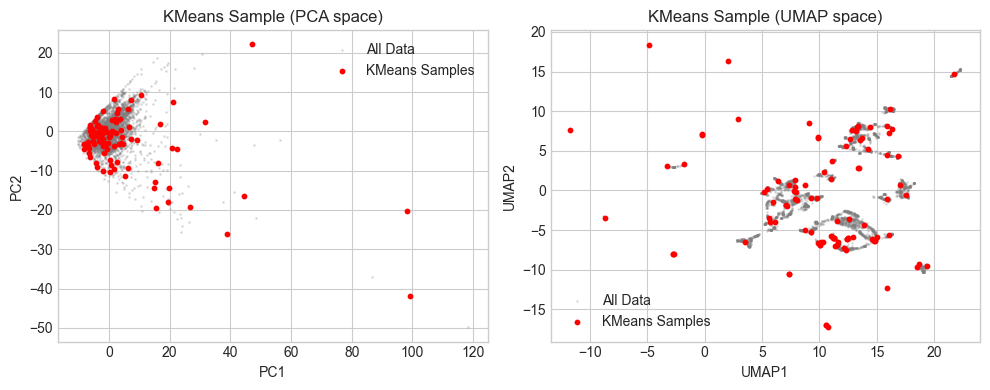

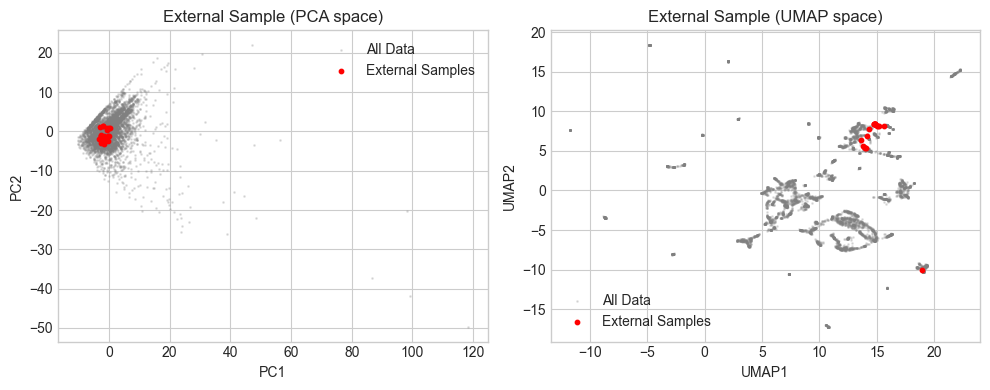

In [17]:
from odor_space_sampling import plot_sampling_projections

gmm_result    = results["gmm"]["indices"]
kmeans_result = results["kmeans"]["indices"]
my_indices    = np.arange(20)  # stand-in for any external index set

plot_sampling_projections(data, [
    (gmm_result,    "GMM"),
    (kmeans_result, "KMeans"),
    (my_indices,    "External"),
])

You can also plot odorant lists that you generate after getting rid of odorants that are not available to purchase or prohibitively expensive.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


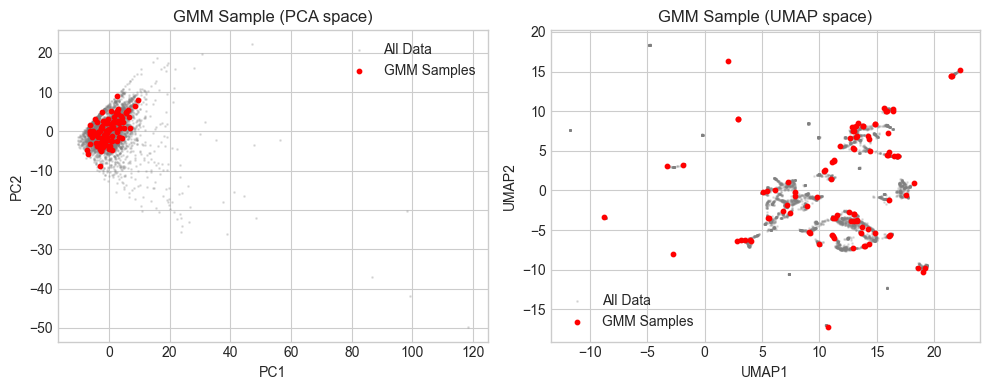

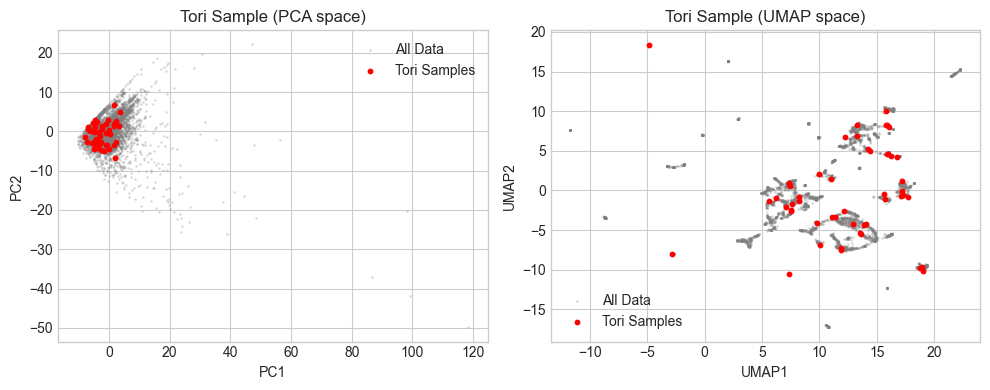

In [19]:
from odor_space_sampling import plot_sampling_projections, create_indices

gmm_result    = results["gmm"]["indices"]
tori_indices  = create_indices(
    fp='../data/TORI_chosen_odorants/table_2.tsv',
    reference_fp='../data/gslf_and_human_data.csv',
    fp_sep='\t',  # if your list is tab separated insead of comma separated 
    reference_fp_sep=','
)

plot_sampling_projections(data, [
    (gmm_result,    "GMM"),
    (tori_indices,    "Tori"),
])

### Coverage

`plot_all_sampling_methods_coverage` measures how well each method covers the full odor space. For each method it computes the mean distance from every odor to its nearest sampled point — lower is better. Also prints mean ± std per method.

uniform: mean min-dist = 19.0756, std = 4.3737
LHS: mean min-dist = 20.0671, std = 5.0859
gaussian: mean min-dist = 8.4111, std = 8.2433
min_max: mean min-dist = 13.4252, std = 3.6779
kmeans: mean min-dist = 6.7125, std = 4.1747
gmm: mean min-dist = 7.8311, std = 7.9709
Tori: mean min-dist = 8.9602, std = 8.1228


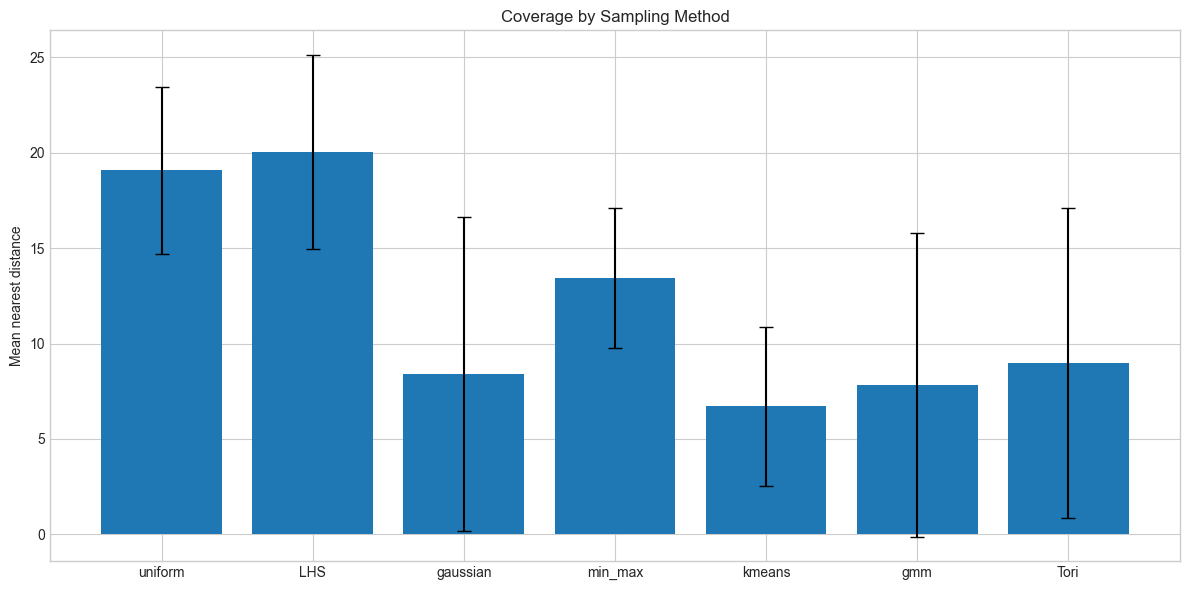

In [23]:
from odor_space_sampling.plotting import plot_all_sampling_methods_coverage

plot_all_sampling_methods_coverage(data, results, extra_methods=[(tori_indices, "Tori")])

### Functional group coverage

`plot_all_sampling_methods_fun_groups` counts how many distinct functional groups appear in each sample. Pass `save_path` to write the missing groups per method to a text file.

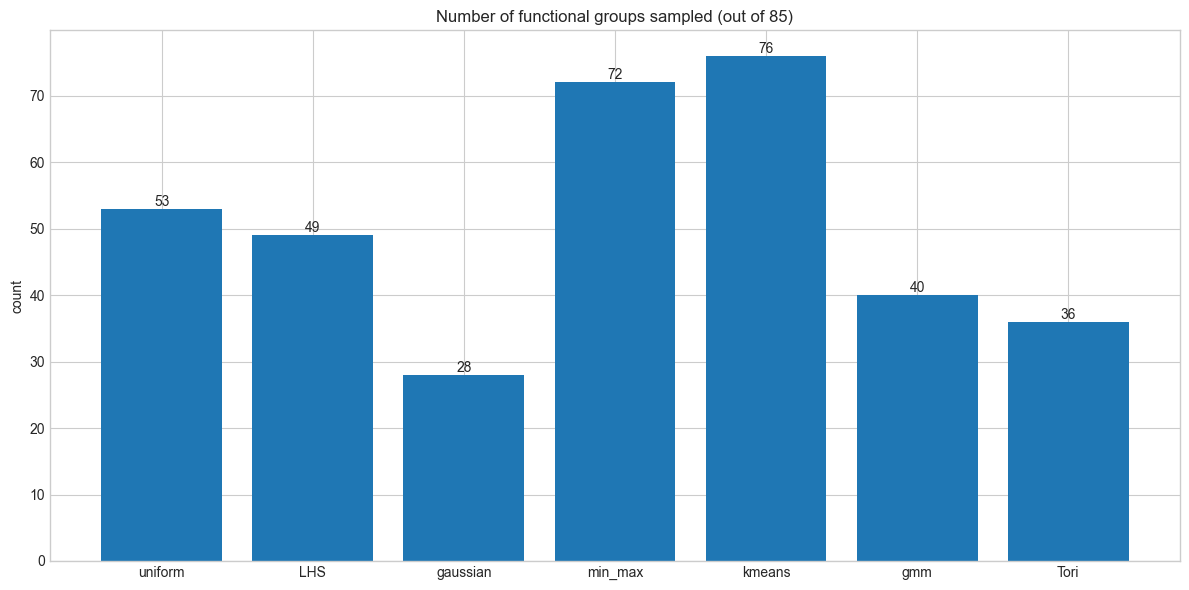

In [25]:
from odor_space_sampling.plotting import plot_all_sampling_methods_fun_groups

plot_all_sampling_methods_fun_groups(
    data,
    results,
    extra_methods=[(tori_indices, "Tori")],
    save_path="../data/example/missing_fn_groups.txt"  # uncomment to save missing groups
)

### Functional group distribution per method

`plot_fun_group_dist` can also be used to compare the functional group profiles of specific sampled subsets. Build an `OdorData` from each method's indices and pass them together.

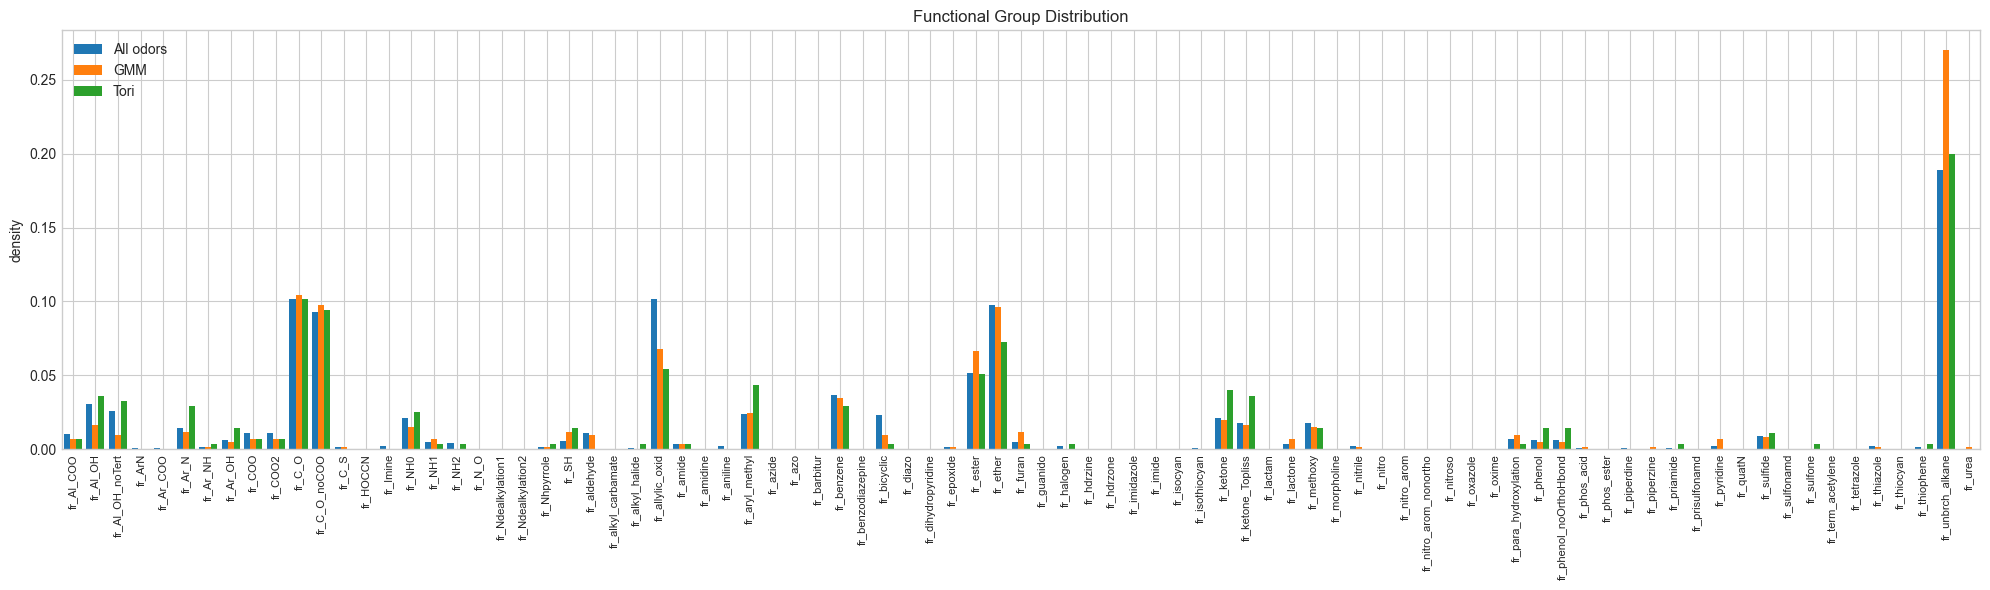

In [28]:
from odor_space_sampling import OdorData, plot_fun_group_dist

def odordata_from_indices(data, indices):
    return OdorData(df=data.df.iloc[indices].reset_index(drop=True), x=data.x[indices])

plot_fun_group_dist([
    (data,                                           "All odors"),
    (odordata_from_indices(data, results["gmm"]["indices"]),    "GMM"),
    (odordata_from_indices(data, tori_indices), "Tori"),
])

### Data type distribution (human / gslf / both)

`plot_all_sampling_methods_data_dist` shows how many human-labelled, gslf-labelled, and dual-labelled odors each method selected. Pass `density=True` to show fractions instead of counts.

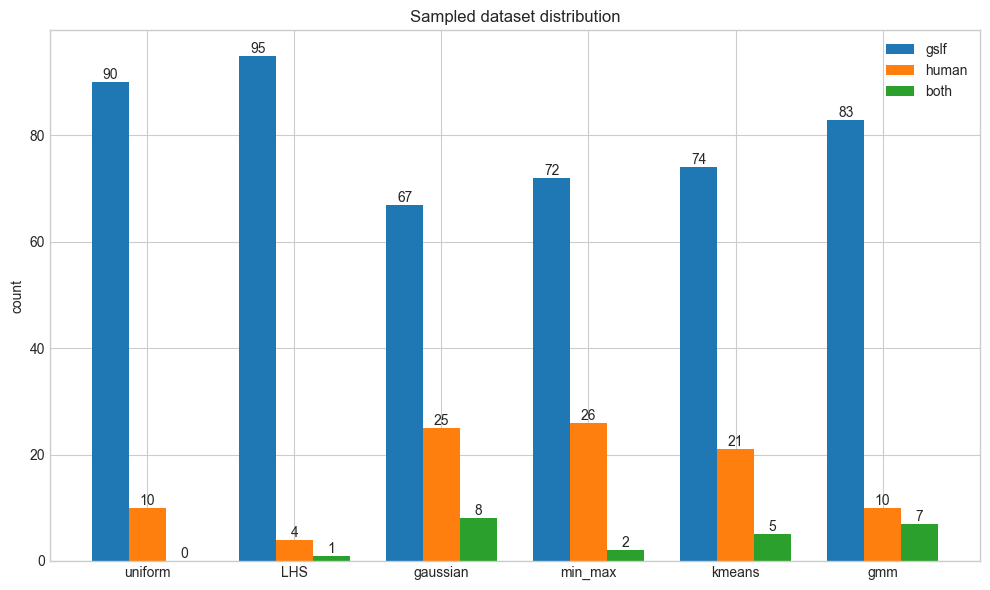

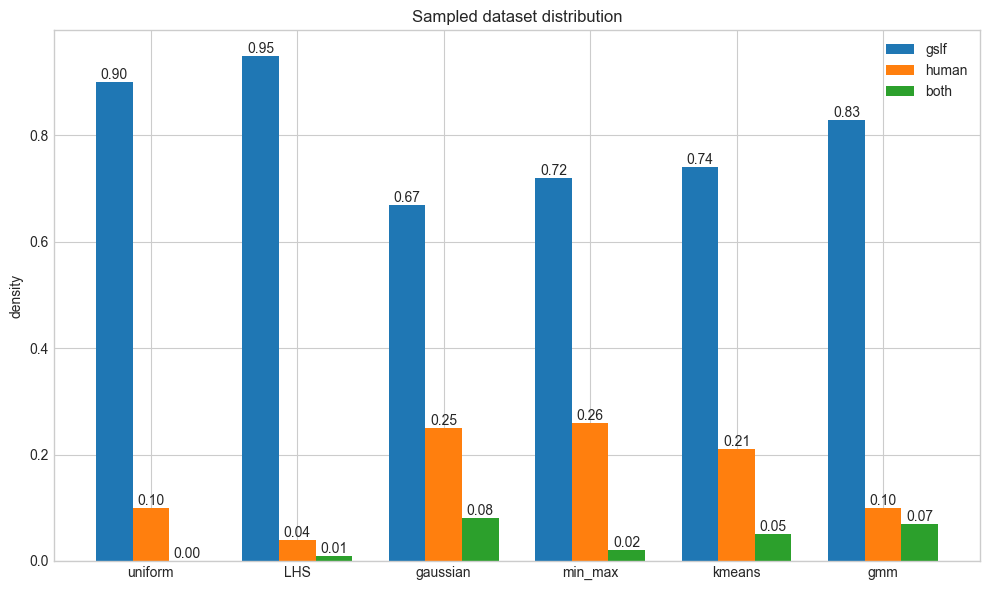

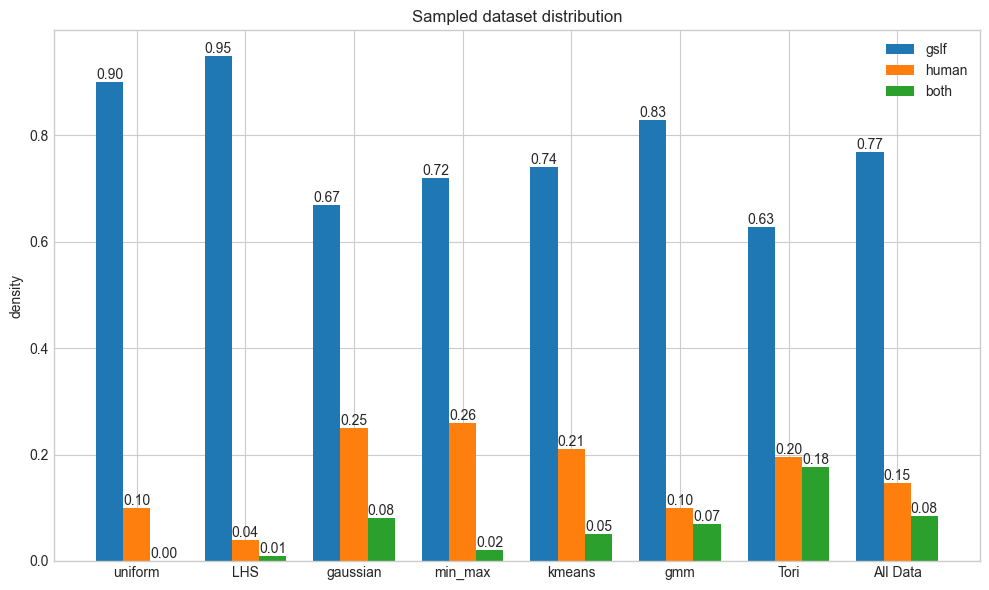

In [35]:
from odor_space_sampling.plotting import plot_all_sampling_methods_data_dist

# raw counts
plot_all_sampling_methods_data_dist(data, results)

# as fractions
plot_all_sampling_methods_data_dist(data, results, density=True)

# with specific indices
plot_all_sampling_methods_data_dist(data, results, extra_methods=[(tori_indices, "Tori"), (np.arange(len(data.df)), "All Data")], density=True)

### KS statistic distributions

`plot_ks_dist` compares one or more sampled subsets against a reference dataset using the Kolmogorov-Smirnov test across all RDKit features. It prints mean and median KS statistics and plots a histogram of the distribution for each method. Values closer to 0 indicate the sample better matches the reference distribution.

uniform
  mean:   0.2822
  median: 0.1897
LHS
  mean:   0.2983
  median: 0.2250
gaussian
  mean:   0.0516
  median: 0.0420
min_max
  mean:   0.1924
  median: 0.1509
kmeans
  mean:   0.0784
  median: 0.0632
gmm
  mean:   0.0367
  median: 0.0336


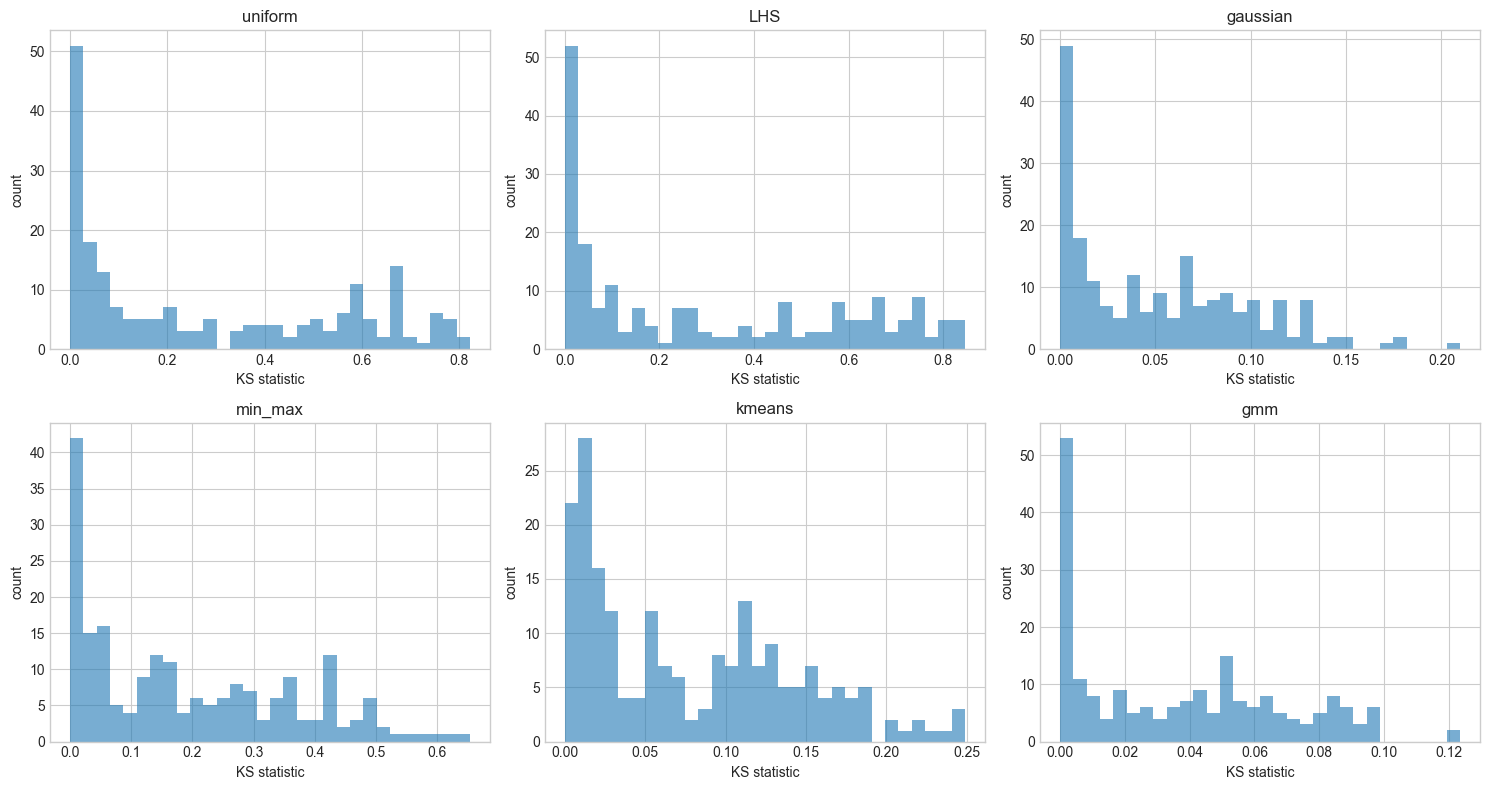

In [36]:
from odor_space_sampling.plotting import plot_ks_dist

# build OdorData objects for each sampled subset
sampled_datasets = [
    (odordata_from_indices(data, results[k]["indices"]), k)
    for k in results
]

# compare all sampling methods against the full dataset as reference
ks_stats = plot_ks_dist(data, sampled_datasets)